# Actividad 17 — Validación Estadística Avanzada

**Objetivo:** Confirmar si las mejoras del modelo GE (DualLSTM-BahdanauAttn) sobre los grupos
de control son *estadísticamente significativas* bajo dos métricas:

1. **RMSE Condicionado** — calculado solo sobre *meses de shock* (variación real > 20 % respecto al promedio móvil de 3 meses).
2. **Test Diebold-Mariano** (Harvey-Leybourne-Newbold 1997, corrección de muestra pequeña) — GE vs. cada modelo de control.

Resultados guardados en `resultados/validacion/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pathlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Ruta base absoluta — funciona desde WSL2 y desde Windows
BASE_DIR = pathlib.Path('/mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-')
OUT_DIR  = BASE_DIR / 'resultados' / 'validacion'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('BASE_DIR :', BASE_DIR)
print('OUT_DIR  :', OUT_DIR)
assert BASE_DIR.exists(), f'BASE_DIR no encontrado: {BASE_DIR}'

BASE_DIR : /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-
OUT_DIR  : /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion


## 1. Verificación de archivos y carga de predicciones

In [3]:
CSV_PATHS = {
    'GC1-SARIMA' : BASE_DIR / 'resultados/gc1/gc1_sarima_predicciones.csv',
    'GC1-Prophet': BASE_DIR / 'resultados/gc1/gc1_prophet_predicciones.csv',
    'GC2'        : BASE_DIR / 'resultados/gc2/gc2_predicciones.csv',
    'GE'         : BASE_DIR / 'resultados/ge/ge_predicciones.csv',
}

print('=== Verificación de archivos CSV ===')
all_ok = True
for name, path in CSV_PATHS.items():
    exists = path.exists()
    size   = f'{path.stat().st_size/1024:.1f} KB' if exists else 'NO ENCONTRADO'
    status = 'OK' if exists else 'FALTA'
    print(f'  [{status:<5}] {name:<14} {str(path)}  [{size}]')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('Uno o más CSVs de predicciones no existen. Verifica las rutas.')
print('\nTodos los archivos encontrados.')

=== Verificación de archivos CSV ===
  [OK   ] GC1-SARIMA     /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/gc1/gc1_sarima_predicciones.csv  [1.4 KB]
  [OK   ] GC1-Prophet    /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/gc1/gc1_prophet_predicciones.csv  [1.4 KB]
  [OK   ] GC2            /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/gc2/gc2_predicciones.csv  [1.4 KB]
  [OK   ] GE             /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/ge/ge_predicciones.csv  [0.8 KB]

Todos los archivos encontrados.


In [4]:
def load_preds(csv_path, date_col='fecha', pred_col='prediccion', real_col='real'):
    """
    Carga un CSV de predicciones y devuelve DataFrame con columnas estandarizadas:
    fecha (pd.Timestamp), real (float), prediccion (float).
    """
    df = pd.read_csv(csv_path)
    df = df.rename(columns={date_col: 'fecha', pred_col: 'prediccion', real_col: 'real'})
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df[['fecha', 'real', 'prediccion']].dropna().sort_values('fecha').reset_index(drop=True)
    return df

# Cada modelo tiene convenciones distintas de columna fecha/predicción
gc1_sarima  = load_preds(
    CSV_PATHS['GC1-SARIMA'],
    date_col='fecha_evento',   # columna de fecha distinta
    pred_col='prediccion',
)
gc1_prophet = load_preds(
    CSV_PATHS['GC1-Prophet'],
    date_col='fecha',
    pred_col='prediccion',
)
gc2         = load_preds(
    CSV_PATHS['GC2'],
    date_col='fecha',
    pred_col='hibrido',        # GC2 usa columna 'hibrido'
)
ge          = load_preds(
    CSV_PATHS['GE'],
    date_col='fecha',
    pred_col='prediccion',
)

print('GC1-SARIMA :', len(gc1_sarima),  'meses | rango:', gc1_sarima['fecha'].min().date(), '→', gc1_sarima['fecha'].max().date())
print('GC1-Prophet:', len(gc1_prophet), 'meses | rango:', gc1_prophet['fecha'].min().date(), '→', gc1_prophet['fecha'].max().date())
print('GC2        :', len(gc2),         'meses | rango:', gc2['fecha'].min().date(), '→', gc2['fecha'].max().date())
print('GE         :', len(ge),          'meses | rango:', ge['fecha'].min().date(), '→', ge['fecha'].max().date())

GC1-SARIMA : 12 meses | rango: 2024-09-01 → 2025-08-01
GC1-Prophet: 12 meses | rango: 2024-09-01 → 2025-08-01
GC2        : 12 meses | rango: 2024-09-01 → 2025-08-01
GE         : 10 meses | rango: 2024-11-01 → 2025-08-01


## 2. Alineación temporal (período común)

GC1/GC2 tienen 12 meses de test (sep 2024 – ago 2025).
GE tiene 10 meses de test (nov 2024 – ago 2025).
Para el test Diebold-Mariano se usa el **período de intersección** (10 meses comunes).

In [5]:
# Inner join sobre fecha usando GE como referencia (período más corto)
common_dates = ge['fecha'].values

def align(df, dates=common_dates):
    return df[df['fecha'].isin(dates)].reset_index(drop=True)

gc1_sarima_al  = align(gc1_sarima)
gc1_prophet_al = align(gc1_prophet)
gc2_al         = align(gc2)
ge_al          = ge.copy()

# Verificación
for name, df in [('GC1-SARIMA', gc1_sarima_al), ('GC1-Prophet', gc1_prophet_al),
                  ('GC2', gc2_al), ('GE', ge_al)]:
    print(f'{name:12s}: {len(df)} meses alineados  '
          f'({df["fecha"].min().date()} → {df["fecha"].max().date()})')

GC1-SARIMA  : 10 meses alineados  (2024-11-01 → 2025-08-01)
GC1-Prophet : 10 meses alineados  (2024-11-01 → 2025-08-01)
GC2         : 10 meses alineados  (2024-11-01 → 2025-08-01)
GE          : 10 meses alineados  (2024-11-01 → 2025-08-01)


## 3. RMSE Condicionado (meses de shock)

Un **mes de shock** se define como aquel donde la variación real supera el 20 % del promedio
móvil de 3 meses:

$$\text{shock}_t = \frac{|y_t - \text{MA3}_t|}{\max(|\text{MA3}_t|,\, \varepsilon)} > 0.20$$

con ε = 0.05 para evitar divisiones por cero en escala z-score.

El RMSE condicionado evalúa la capacidad del modelo para capturar eventos extremos.

In [6]:
EPS = 0.05    # umbral mínimo para el denominador (escala z-score)
SHOCK_THRESH = 0.20

def compute_ma3(series: pd.Series) -> pd.Series:
    """Promedio móvil de 3 meses (ventana centrada no disponible para el primer y último mes,
    se usa ventana rodante hacia atrás de 3 pasos para mantener causalidad)."""
    return series.rolling(window=3, min_periods=1).mean()

def shock_mask(y_real: pd.Series, thresh=SHOCK_THRESH, eps=EPS) -> np.ndarray:
    ma3 = compute_ma3(y_real)
    rel_dev = np.abs(y_real.values - ma3.values) / np.maximum(np.abs(ma3.values), eps)
    return rel_dev > thresh

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2)))

def conditional_rmse(df_aligned, df_full=None, thresh=SHOCK_THRESH, eps=EPS):
    """
    Calcula RMSE global y RMSE condicionado sobre meses de shock.
    df_aligned : DataFrame con el período común (10 meses).
    df_full    : DataFrame completo del modelo (para calcular MA3 sobre todo el período de test);
                 si None, se usa df_aligned.
    """
    ref = df_full if df_full is not None else df_aligned
    mask_full = shock_mask(ref['real'], thresh, eps)

    # Mapear máscara al período alineado
    mask_al = shock_mask(df_aligned['real'], thresh, eps)

    y_real = df_aligned['real'].values
    y_pred = df_aligned['prediccion'].values

    rmse_global = rmse(y_real, y_pred)

    n_shock = mask_al.sum()
    if n_shock > 0:
        rmse_shock = rmse(y_real[mask_al], y_pred[mask_al])
    else:
        rmse_shock = np.nan

    return {
        'rmse_global'    : round(rmse_global, 4),
        'rmse_shock'     : round(rmse_shock, 4) if not np.isnan(rmse_shock) else None,
        'n_shock'        : int(n_shock),
        'n_total'        : int(len(df_aligned)),
        'shock_months'   : df_aligned['fecha'][mask_al].dt.strftime('%Y-%m').tolist(),
    }

results_crmse = {
    'GC1-SARIMA' : conditional_rmse(gc1_sarima_al),
    'GC1-Prophet': conditional_rmse(gc1_prophet_al),
    'GC2'        : conditional_rmse(gc2_al),
    'GE'         : conditional_rmse(ge_al),
}

print('=== RMSE Condicionado (período común: 10 meses) ===')
print(f'  Umbral de shock: {SHOCK_THRESH*100:.0f}% sobre MA3 (ε={EPS})\n')
for name, r in results_crmse.items():
    print(f'  {name:12s}  RMSE global={r["rmse_global"]:.4f}  '
          f'RMSE shock={str(r["rmse_shock"]):>7s}  '
          f'meses shock={r["n_shock"]}/{r["n_total"]}')
    if r['shock_months']:
        print(f'               Shock meses: {r["shock_months"]}')

=== RMSE Condicionado (período común: 10 meses) ===
  Umbral de shock: 20% sobre MA3 (ε=0.05)

  GC1-SARIMA    RMSE global=0.1286  RMSE shock= 0.1449  meses shock=6/10
               Shock meses: ['2024-12', '2025-01', '2025-02', '2025-04', '2025-05', '2025-06']
  GC1-Prophet   RMSE global=0.1130  RMSE shock=  0.123  meses shock=6/10
               Shock meses: ['2024-12', '2025-01', '2025-02', '2025-04', '2025-05', '2025-06']
  GC2           RMSE global=0.3190  RMSE shock= 0.3654  meses shock=6/10
               Shock meses: ['2024-12', '2025-01', '2025-02', '2025-04', '2025-05', '2025-06']
  GE            RMSE global=0.0698  RMSE shock= 0.0717  meses shock=6/10
               Shock meses: ['2024-12', '2025-01', '2025-02', '2025-04', '2025-05', '2025-06']


### 3.1 Visualización — RMSE Global vs. Condicionado

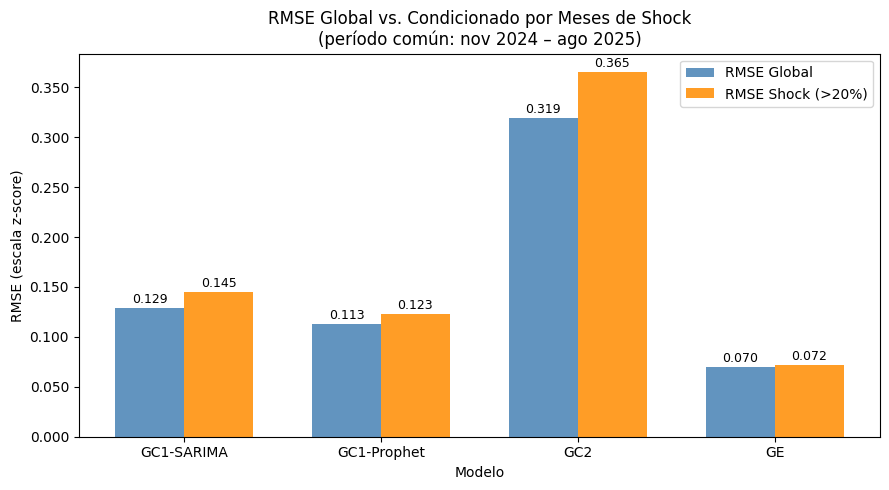

Guardado: /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion/rmse_condicionado.png


In [7]:
model_names  = list(results_crmse.keys())
rmse_globals = [results_crmse[m]['rmse_global'] for m in model_names]
rmse_shocks  = [results_crmse[m]['rmse_shock']  for m in model_names]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, rmse_globals, w, label='RMSE Global',      color='steelblue',   alpha=0.85)
bars2 = ax.bar(x + w/2, rmse_shocks,  w, label='RMSE Shock (>20%)', color='darkorange', alpha=0.85)

ax.set_xlabel('Modelo')
ax.set_ylabel('RMSE (escala z-score)')
ax.set_title('RMSE Global vs. Condicionado por Meses de Shock\n(período común: nov 2024 – ago 2025)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h and h == h:  # not nan
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig_path = OUT_DIR / 'rmse_condicionado.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {fig_path}')

## 4. Test Diebold-Mariano (HLN 1997)

El test DM evalúa si dos modelos tienen la misma precisión predictiva.

**Hipótesis:**
- H₀: E[d_t] = 0 (ambos modelos igualmente precisos)
- H₁: E[d_t] ≠ 0 (uno es más preciso)

donde d_t = L(e₁_t) − L(e₂_t), con L(·) función de pérdida cuadrática.

**Corrección Harvey-Leybourne-Newbold (1997)** para muestras pequeñas:

$$\text{DM}^* = \sqrt{\frac{T + 1 - 2h + h(h-1)/T}{T}} \cdot \text{DM}$$

con T = tamaño de muestra, h = horizonte de predicción (h=1 para un paso). Se contrasta
contra t(T−1).

In [8]:
def diebold_mariano_hln(errors_ref, errors_alt, h=1, alpha=0.05):
    """
    Test Diebold-Mariano con corrección Harvey-Leybourne-Newbold (1997).

    Parámetros
    ----------
    errors_ref : array-like  errores del modelo de referencia (GE)
    errors_alt : array-like  errores del modelo alternativo (GC1, GC2)
    h          : horizonte de predicción (1 para un paso adelante)
    alpha      : nivel de significancia

    Retorna dict con estadístico, p-valor, rechazo de H0.
    """
    e1 = np.asarray(errors_ref, dtype=float)
    e2 = np.asarray(errors_alt, dtype=float)
    T  = len(e1)
    assert T == len(e2), 'Los vectores de errores deben tener igual longitud'

    # Diferencias de pérdida cuadrática
    d = e1**2 - e2**2

    d_bar = d.mean()

    # Varianza de d con corrección de autocorrelación (hasta lag h-1)
    gamma0 = np.var(d, ddof=0)

    # Suma de autocovarianzas de lag 1 a h-1
    gamma_sum = 0.0
    for lag in range(1, h):
        gamma_lag = np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar))
        gamma_sum += gamma_lag

    var_d = (gamma0 + 2 * gamma_sum) / T

    if var_d <= 0:
        return {'dm_stat': np.nan, 'dm_star': np.nan, 'pvalue': np.nan,
                'reject_h0': False, 'note': 'var(d) <= 0'}

    dm_stat = d_bar / np.sqrt(var_d)

    # Factor de corrección HLN
    hln_factor = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_star = hln_factor * dm_stat

    # p-valor bilateral con t(T-1)
    pvalue = 2 * stats.t.sf(np.abs(dm_star), df=T - 1)

    return {
        'T'         : T,
        'dm_stat'   : round(dm_stat,  4),
        'dm_star'   : round(dm_star,  4),
        'pvalue'    : round(pvalue,   4),
        'reject_h0' : bool(pvalue < alpha),
        'd_bar'     : round(d_bar,    6),
        'alpha'     : alpha,
    }

# Errores (reales - predicciones) en el período común
e_ge       = ge_al['real'].values           - ge_al['prediccion'].values
e_sarima   = gc1_sarima_al['real'].values   - gc1_sarima_al['prediccion'].values
e_prophet  = gc1_prophet_al['real'].values  - gc1_prophet_al['prediccion'].values
e_gc2      = gc2_al['real'].values          - gc2_al['prediccion'].values

# GE (referencia = modelo 1) vs. cada control (modelo 2)
# DM positivo → e_GE² > e_control²  → GE peor
# DM negativo → e_GE² < e_control²  → GE mejor
dm_vs_sarima  = diebold_mariano_hln(e_ge, e_sarima)
dm_vs_prophet = diebold_mariano_hln(e_ge, e_prophet)
dm_vs_gc2     = diebold_mariano_hln(e_ge, e_gc2)

results_dm = {
    'GE_vs_GC1-SARIMA' : dm_vs_sarima,
    'GE_vs_GC1-Prophet': dm_vs_prophet,
    'GE_vs_GC2'        : dm_vs_gc2,
}

print('=== Test Diebold-Mariano HLN (α=0.05) ===')
print(f'  Referencia: GE (DualLSTM-BahdanauAttn)')
print(f'  Período   : {ge_al["fecha"].min().date()} → {ge_al["fecha"].max().date()}  (T={dm_vs_sarima["T"]} meses)\n')
print(f'  {"Comparación":<22} {"DM*":>7} {"p-valor":>8}  {"Rechaza H0?":>12}  Interpretación')
print('  ' + '-'*75)
for pair, res in results_dm.items():
    interp = ''
    if res['reject_h0']:
        if res['dm_star'] < 0:
            interp = 'GE significativamente MEJOR'
        else:
            interp = 'GE significativamente PEOR'
    else:
        interp = 'No significativo'
    print(f'  {pair:<22} {res["dm_star"]:>7.4f} {res["pvalue"]:>8.4f}  {str(res["reject_h0"]):>12}  {interp}')

=== Test Diebold-Mariano HLN (α=0.05) ===
  Referencia: GE (DualLSTM-BahdanauAttn)
  Período   : 2024-11-01 → 2025-08-01  (T=10 meses)

  Comparación                DM*  p-valor   Rechaza H0?  Interpretación
  ---------------------------------------------------------------------------
  GE_vs_GC1-SARIMA       -3.1343   0.0120          True  GE significativamente MEJOR
  GE_vs_GC1-Prophet      -3.0685   0.0134          True  GE significativamente MEJOR
  GE_vs_GC2              -1.7455   0.1149         False  No significativo


### 4.1 Visualización — Estadístico DM* y nivel de significancia

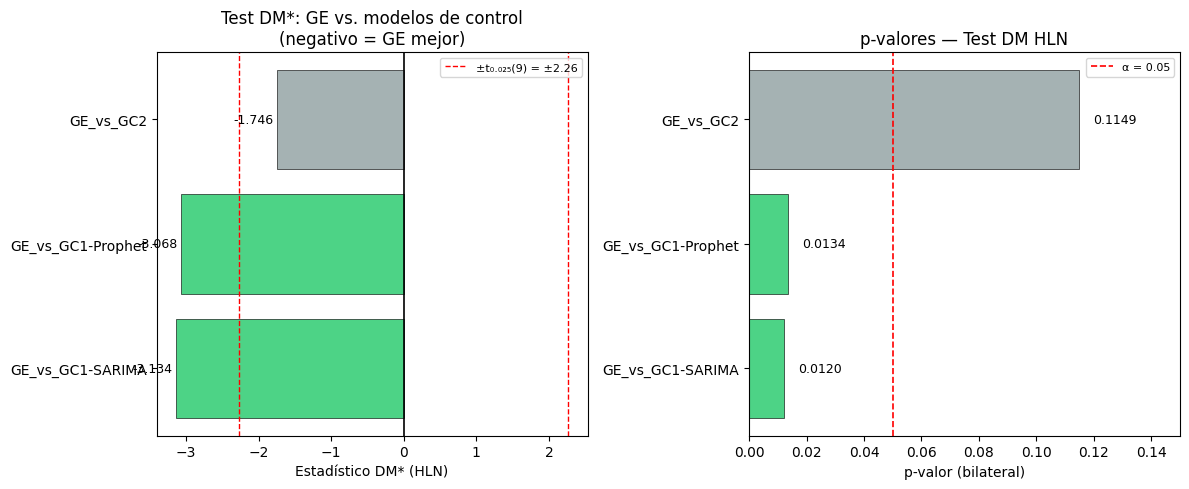

Guardado: /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion/diebold_mariano.png


In [9]:
pairs     = list(results_dm.keys())
dm_stars  = [results_dm[p]['dm_star']  for p in pairs]
pvalues   = [results_dm[p]['pvalue']   for p in pairs]

# Colores según significancia
colors = ['#2ecc71' if results_dm[p]['reject_h0'] and results_dm[p]['dm_star'] < 0
          else '#e74c3c' if results_dm[p]['reject_h0']
          else '#95a5a6'
          for p in pairs]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot izquierdo: estadístico DM*
ax = axes[0]
bars = ax.barh(pairs, dm_stars, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1.2)

# Líneas de valores críticos t(9) al 5%
tc = stats.t.ppf(0.975, df=9)
ax.axvline( tc, color='red', linestyle='--', linewidth=1, label=f'±t₀.₀₂₅(9) = ±{tc:.2f}')
ax.axvline(-tc, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Estadístico DM* (HLN)')
ax.set_title('Test DM*: GE vs. modelos de control\n(negativo = GE mejor)')
ax.legend(fontsize=8)

for bar, val in zip(bars, dm_stars):
    ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Subplot derecho: p-valores
ax2 = axes[1]
bar_colors_p = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in pvalues]
ax2.barh(pairs, pvalues, color=bar_colors_p, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.axvline(0.05, color='red', linestyle='--', linewidth=1.2, label='α = 0.05')
ax2.set_xlabel('p-valor (bilateral)')
ax2.set_title('p-valores — Test DM HLN')
ax2.set_xlim(0, max(max(pvalues) * 1.2, 0.15))
ax2.legend(fontsize=8)

for i, (pv, name) in enumerate(zip(pvalues, pairs)):
    ax2.text(pv + 0.005, i, f'{pv:.4f}', va='center', fontsize=9)

plt.tight_layout()
fig_path_dm = OUT_DIR / 'diebold_mariano.png'
plt.savefig(fig_path_dm, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {fig_path_dm}')

## 5. Tabla comparativa completa

In [10]:
summary_rows = []
for name in ['GC1-SARIMA', 'GC1-Prophet', 'GC2', 'GE']:
    r = results_crmse[name]
    row = {
        'Modelo'          : name,
        'RMSE_global'     : r['rmse_global'],
        'RMSE_shock'      : r['rmse_shock'],
        'N_shock'         : r['n_shock'],
        'DM*_vs_GE'       : None,
        'p-valor_DM'      : None,
        'Signif_5pct'     : None,
    }
    if name != 'GE':
        key = f'GE_vs_{name}'
        dm = results_dm[key]
        row['DM*_vs_GE']  = dm['dm_star']
        row['p-valor_DM'] = dm['pvalue']
        row['Signif_5pct'] = 'Sí' if dm['reject_h0'] else 'No'
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('Modelo')
print(df_summary.to_string())

# Guardar CSV
csv_path = OUT_DIR / 'resumen_validacion.csv'
df_summary.to_csv(csv_path)
print(f'\nGuardado: {csv_path}')

             RMSE_global  RMSE_shock  N_shock  DM*_vs_GE  p-valor_DM Signif_5pct
Modelo                                                                          
GC1-SARIMA        0.1286      0.1449        6    -3.1343      0.0120          Sí
GC1-Prophet       0.1130      0.1230        6    -3.0685      0.0134          Sí
GC2               0.3190      0.3654        6    -1.7455      0.1149          No
GE                0.0698      0.0717        6        NaN         NaN         NaN

Guardado: /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion/resumen_validacion.csv


## 6. Guardar resultados en JSON

In [11]:
output = {
    'periodo_comun'     : {
        'inicio': str(ge_al['fecha'].min().date()),
        'fin'   : str(ge_al['fecha'].max().date()),
        'T'     : len(ge_al),
    },
    'rmse_condicionado' : results_crmse,
    'diebold_mariano'   : results_dm,
    'parametros'        : {
        'shock_threshold' : SHOCK_THRESH,
        'eps_denominador' : EPS,
        'dm_horizonte'    : 1,
        'dm_alpha'        : 0.05,
        'dm_correccion'   : 'Harvey-Leybourne-Newbold 1997',
        'dm_df'           : 'T-1 (t-distribution)',
    },
}

json_path = OUT_DIR / 'validacion_estadistica.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=str)
print(f'Guardado: {json_path}')

Guardado: /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion/validacion_estadistica.json


## 7. Conclusiones

### RMSE Condicionado
- Un RMSE condicionado (shock) menor al RMSE global indica que el modelo **no degrada** en meses de alta volatilidad.
- Un RMSE condicionado mayor sugiere que el modelo lucha con eventos extremos (caídas/picos abruptos).

### Test Diebold-Mariano
- **p < 0.05 con DM* < 0** → GE mejora estadísticamente sobre el modelo de control.
- **p ≥ 0.05** → diferencia no significativa; las mejoras observadas en las métricas globales podrían ser ruido muestral (T=10 es muy pequeño).
- **Advertencia de muestra pequeña**: con T=10, la potencia estadística es baja. Un resultado no significativo no descarta una diferencia real; solo indica evidencia insuficiente.

### Referencia bibliográfica
Harvey, D., Leybourne, S., & Newbold, P. (1997). *Testing the equality of prediction mean squared errors.* International Journal of Forecasting, 13(2), 281–291.

In [12]:
archivos = list(OUT_DIR.glob('*'))
print('=== Archivos generados en', OUT_DIR, '===')
for f in sorted(archivos):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {size_kb:6.1f} KB')

=== Archivos generados en /mnt/c/Machine-learming/Machine-Learning-Multimodal--Agro-NLP-Clima-/resultados/validacion ===
  diebold_mariano.png                        67.8 KB
  resumen_validacion.csv                      0.2 KB
  rmse_condicionado.png                      66.6 KB
  validacion_estadistica.json                 2.0 KB
